# 3.2 导读与数学基础：向量召回

> 阅读版与 Web 应用内容一致；实验数值来自本 Notebook 的已执行输出。

## Goal

在进入 DSSM 与 MIND 前，理解向量空间、对比学习、负样本、ANN、Top-K 指标和单兴趣/多兴趣的差别。

## Setup

默认 `smoke` 档使用仓库内固定版本的 GroupLens **MovieLens latest-small** 真实行为子集，CPU 可重复执行；`full` 档只扩大真实数据规模与训练配置，不切换到合成数据。数据包含真实匿名用户、电影、评分和时间戳；实验只做确定性截取与任务重构，不随机制造交互、标签或行为序列。原始许可与引用保存在 `data/ml-latest-small/README.txt`。

**主要资料：** [DSSM](https://www.microsoft.com/en-us/research/publication/learning-deep-structured-semantic-models-for-web-search-using-clickthrough-data/) · [MIND](https://arxiv.org/abs/1904.08030) · [YouTube DNN](https://research.google/pubs/deep-neural-networks-for-youtube-recommendations/)

In [1]:
from pathlib import Path
import os, sys, json
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))
os.environ.setdefault("RECSYS_PROFILE", "smoke")
PROFILE = os.environ["RECSYS_PROFILE"]
from recsys_lab.data import load_movielens, movielens_provenance
real_ratings, real_movies = load_movielens()
REAL_DATASET = movielens_provenance(real_ratings)
print({"profile": PROFILE, "root": str(ROOT), "real_dataset": REAL_DATASET})
assert REAL_DATASET["randomly_fabricated_rows"] == 0

/usr/local/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


{'profile': 'smoke', 'root': '/workspace', 'real_dataset': {'dataset': 'MovieLens latest-small (GroupLens, generated 2018-09-26)', 'source': 'https://files.grouplens.org/datasets/movielens/ml-latest-small.zip', 'license_file': '/workspace/data/ml-latest-small/README.txt', 'rows_used': 26732, 'users_used': 120, 'items_used': 600, 'time_min_utc': '1996-10-17T11:51:49+00:00', 'time_max_utc': '2018-09-13T21:38:16+00:00', 'positive_rule': 'like := observed rating >= 4.0; very_like := observed rating >= 4.5', 'randomly_fabricated_rows': 0}}


## 如何使用本导读

先阅读布局和论文问题，再运行共同数学演示。完成 Checks 后进入独立算法 Notebook；各算法会重新给出本模型的公式和更小的 Python 演示，不要求记住本页所有公式。

## 本章布局与选型地图

| 子章节 | 用户表示 | 检索次数 | 优势 | 主要代价 |
|---|---:|---:|---|---|
| 3.2.1 DSSM | 1 个向量 | 1 | 简单、低延迟、ANN 友好 | 多兴趣被平均 |
| 3.2.2 MIND | K 个兴趣向量 | K | 覆盖多意图与长尾 | 路由、合并、去重成本 |
| 3.2 总结 | 读取两个实验结果 | — | 同口径看 Recall 与成本 | smoke 不是 benchmark |

DSSM 适合通用亿级目录；MIND 适合行为长、意图明显分裂的内容或电商用户。工业系统通常还保留热门、ItemCF、规则和内容召回通道。

## 来源论文解读

- **Huang et al. (2013)** 用点击数据让两侧表示进入同一语义空间。后来推荐系统将这一结构发展为双塔：item 可离线编码，线上只做用户编码和 ANN。
- **YouTube DNN (2016)** 明确区分 candidate generation 与 ranking，并讨论 sampled softmax 和训练/服务分布。
- **MIND (2019)** 用动态路由抽取多个兴趣胶囊，训练时根据目标选择相关兴趣。

论文中的离线提升不等于任意目录上的线上增益；负采样、索引新鲜度和候选合并常比换一层 MLP 更重要。

## 共同数学：相似度、Softmax 与 Recall

归一化向量的内积 $s(u,i)=u^\top v_i$ 等于余弦相似度。对一个正物品和若干负物品，可用

$$P(i^+|u)=\frac{\exp(s(u,i^+)/\tau)}{\sum_j\exp(s(u,i_j)/\tau)}$$

训练，其中温度 $\tau$ 控制分布尖锐程度。in-batch negative 把同一批次其他正物品当负样本，效率高但可能出现假负样本。

召回阶段常看 $\mathrm{Recall@K}=|TopK\cap Relevant|/|Relevant|$。DSSM 只有一个 $u$；MIND 使用 $K$ 个 $u_k$，候选分数为 $\max_k u_k^\top v_i$。

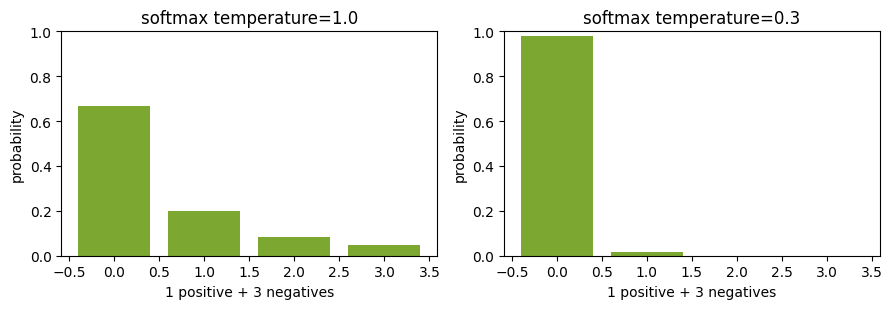

{'single_scores': [0.5, 0.5, -0.5], 'multi_interest_scores': [1.0, 1.0, 0.0]}


In [2]:
import numpy as np, matplotlib.pyplot as plt
scores=np.array([2.4,1.2,.3,-.2]); temperatures=[1.0,.3]
fig,axes=plt.subplots(1,2,figsize=(9,3.2))
for ax,tau in zip(axes,temperatures):
    probability=np.exp(scores/tau); probability/=probability.sum()
    ax.bar(range(len(scores)),probability,color='#7ca832'); ax.set(title=f'softmax temperature={tau}',xlabel='1 positive + 3 negatives',ylabel='probability',ylim=(0,1))
plt.tight_layout(); plt.show()
single=np.array([.5,.5]); interests=np.array([[1.,0.],[0.,1.]]); candidates=np.array([[1.,0.],[0.,1.],[-1.,0.]])
print({'single_scores':(candidates@single).tolist(),'multi_interest_scores':(interests@candidates.T).max(0).tolist()})

## 学习顺序

1. 说清业务阶段和输入输出；2. 手算共享数学；3. 进入每个独立算法；4. 执行训练与推理；5. 最后打开章节总结读取实际结果。

## Checks

In [3]:
def recall_at_k(ranked,relevant,k):
    return len(set(ranked[:k])&set(relevant))/len(relevant)
assert recall_at_k([2,5,1,7],[1,2,8],3)==2/3
print('PASS：Softmax 概率、单/多兴趣分数与 Recall 示例正确。')

PASS：Softmax 概率、单/多兴趣分数与 Recall 示例正确。


## Next Steps

从左侧 Notebook 导航进入本章第一个算法。遇到公式时依次检查：符号代表什么、数组形状是什么、用小数字怎么算、代码输出是否符合直觉。